# 미니프로젝트: 머신러닝 프로세스 (Vibe Coding)

#### <목표>
오늘 배운 머신러닝 프로세스를 **제조 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- AI4I 2020 Predictive Maintenance (예지 정비)
- 10,000개 제조 장비 운전 데이터

| 변수명 | 설명 |
|:---:|:---|
| Type | 제품 품질 등급 (L: Low, M: Medium, H: High) |
| Air temperature | 공기 온도 [K] |
| Process temperature | 공정 온도 [K] |
| Rotational speed | 회전 속도 [rpm] |
| Torque | 토크 [Nm] |
| Tool wear | 공구 마모 시간 [min] |
| Machine failure | 기계 고장 여부 (0: 정상, 1: 고장) |
| TWF, HDF, PWF, OSF, RNF | 고장 유형별 발생 여부 |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 회귀 | `Torque` | 운전 조건(온도, 회전속도, 공구마모 등)으로 토크 예측 |
| 분류 | `Machine failure` | 운전 조건으로 기계 고장 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day1_miniproject.csv` 파일을 사용하기
- 하나의 원본 데이터에서 태스크별로 데이터프레임을 분리하기
    - **회귀용 (Regression):** 타겟 = `Torque`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Tool wear
    - **분류용 (Classification):** 타겟 = `Machine failure`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear

**[과제]** 써니는 오늘부로 제조 설비 운전 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 불러오고, 회귀용/분류용 데이터셋을 각각 어떻게 구성해야 할지 AI와 상의해서 코드를 작성하세요.

In [ ]:
# 주요 라이브러리 호출
import pandas as pd
import numpy as np

# 데이터 탐색을 위한 시각화 라이브러리
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

# 원본 데이터 불러오기
df = pd.read_csv(r"dataset/day1_miniproject.csv")

# 태스크별 입력/타겟 변수 정의
reg_features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Tool wear",
]
reg_target = "Torque"

clf_features = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
]
clf_target = "Machine failure"

# 회귀용 / 분류용 데이터프레임 분리
Regression = df[reg_features + [reg_target]].copy()
Classification = df[clf_features + [clf_target]].copy()

# 기본 전처리: 결측치 확인
print("=== 원본 데이터 ===")
print(f"shape: {df.shape}")
print(f"결측치:\n{df.isnull().sum()}\n")

print("=== 회귀용 데이터 (Regression) ===")
print(f"shape: {Regression.shape}")
print(f"타겟: {reg_target} | 입력: {reg_features}")
display(Regression.head())

print("\n=== 분류용 데이터 (Classification) ===")
print(f"shape: {Classification.shape}")
print(f"타겟: {clf_target} | 입력: {clf_features}")
display(Classification.head())

---
## 1) 데이터 탐색 (EDA)

### 1-1) Value 기반 탐색

**[과제]** 써니는 본격적인 분석에 앞서 데이터가 어떻게 생겼는지 먼저 파악하고 싶습니다. AI와 어떠한 데이터 정보를 확인하면 좋을지 상의해보고 관련 정보를 확인해보세요.

In [ ]:
# ===== 1-1-1) 구조적 정보 =====

# 데이터 크기 확인 (행, 열)
print("[회귀] Regression.shape:", Regression.shape)
print("[분류] Classification.shape:", Classification.shape)

# 데이터 정보 확인: 변수명, 자료형, 결측치 개수, 메모리 사용량
print("\n--- Regression.info() ---")
Regression.info()

print("\n--- Classification.info() ---")
Classification.info()

# 앞부분 데이터 미리보기
print("\n--- Regression.head(3) ---")
display(Regression.head(3))

print("\n--- Classification.head(3) ---")
display(Classification.head(3))

# 결측치 확인
print("\n--- 결측치 개수 ---")
print("Regression:\n", Regression.isnull().sum())
print("\nClassification:\n", Classification.isnull().sum())

[회귀] Regression.shape: (10000, 6)
[분류] Classification.shape: (10000, 7)

--- Regression.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Tool wear            10000 non-null  int64  
 5   Torque               10000 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 468.9+ KB

--- Classification.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  

,Type,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
0,M,298.1,308.6,1551,0,42.8
1,L,298.2,308.7,1408,3,46.3
2,L,298.1,308.5,1498,5,49.4



--- Classification.head(3) ---


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0



--- 결측치 개수 ---
Regression:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Tool wear              0
Torque                 0
dtype: int64

Classification:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
dtype: int64


In [ ]:
# ===== 1-1-2) 통계적 정보 =====

# 기술통계량 (범주형 변수 포함)
print("--- Regression.describe(include='all') ---")
display(Regression.describe(include="all"))

print("\n--- Classification.describe(include='all') ---")
display(Classification.describe(include="all"))

# 변수별 고유값 개수
print("\n--- 변수별 고유값 개수 (nunique) ---")
print("Regression:\n", Regression.nunique())
print("\nClassification:\n", Classification.nunique())

# 분류 타겟(Machine failure) 범주별 빈도
print("\n--- Machine failure 범주별 빈도 ---")
print(Classification["Machine failure"].value_counts())
print("\n비율:")
print(Classification["Machine failure"].value_counts(normalize=True).round(4))

# 범주형 입력 변수(Type) 분포
print("\n--- Type 범주별 빈도 ---")
print("Regression:\n", Regression["Type"].value_counts())
print("\nClassification:\n", Classification["Type"].value_counts())

--- Regression.describe(include='all') ---


,Type,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,3,NaN,NaN,NaN,NaN,NaN
top,L,NaN,NaN,NaN,NaN,NaN
freq,6000,NaN,NaN,NaN,NaN,NaN
mean,NaN,300.004930,310.005560,1538.776100,107.951000,39.986910
std,NaN,2.000259,1.483734,179.284096,63.654147,9.968934
min,NaN,295.300000,305.700000,1168.000000,0.000000,3.800000
25%,NaN,298.300000,308.800000,1423.000000,53.000000,33.200000
50%,NaN,300.100000,310.100000,1503.000000,108.000000,40.100000
75%,NaN,301.500000,311.100000,1612.000000,162.000000,46.800000



--- Classification.describe(include='all') ---


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN
top,L,NaN,NaN,NaN,NaN,NaN,NaN
freq,6000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000



--- 변수별 고유값 개수 (nunique) ---
Regression:
 Type                     3
Air temperature         93
Process temperature     82
Rotational speed       941
Tool wear              246
Torque                 577
dtype: int64

Classification:
 Type                     3
Air temperature         93
Process temperature     82
Rotational speed       941
Torque                 577
Tool wear              246
Machine failure          2
dtype: int64

--- Machine failure 범주별 빈도 ---
Machine failure
0    9661
1     339
Name: count, dtype: int64

비율:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

--- Type 범주별 빈도 ---
Regression:
 Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Classification:
 Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


### 1-2) Graph 기반 탐색

#### 1-2-1) 단일 변수 분포

**[과제]** 써니는 변수들의 분포가 어떤 모양인지 한눈에 살펴보고 싶습니다. 여러 수치형 변수를 효율적으로 한 번에 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

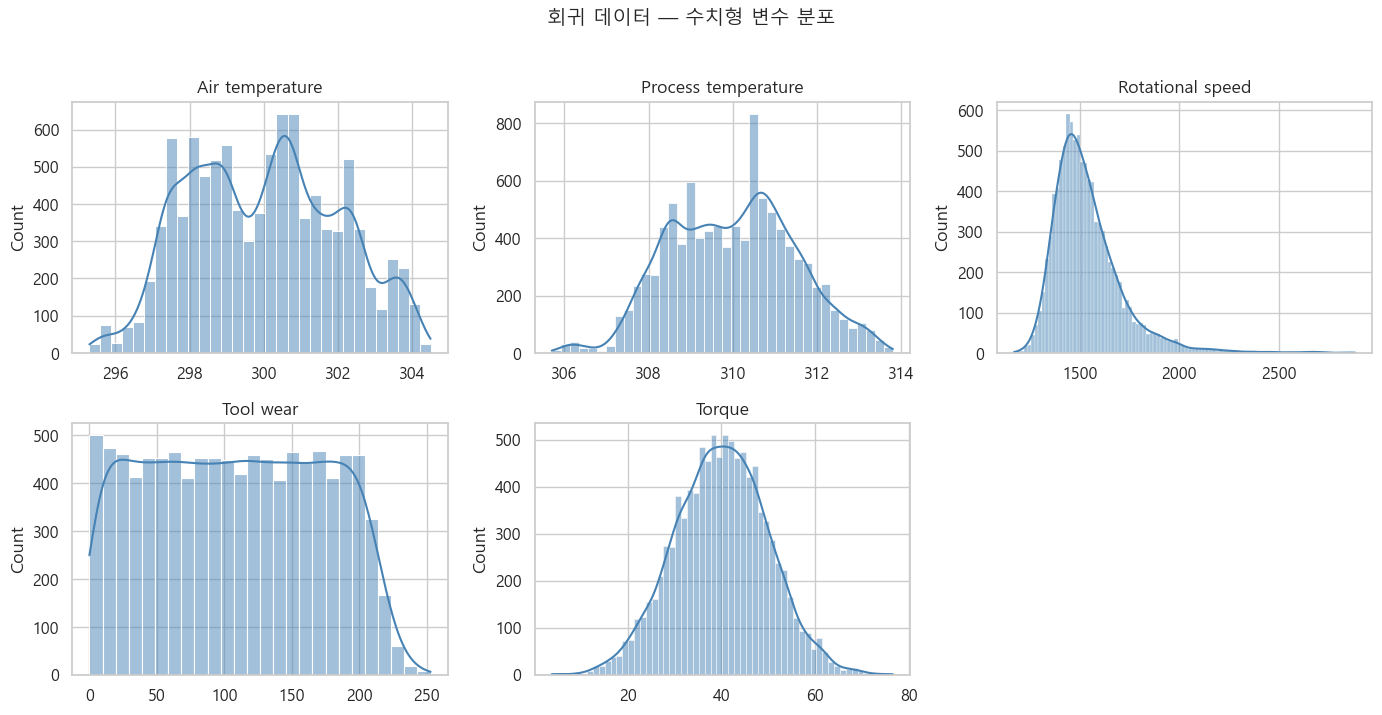

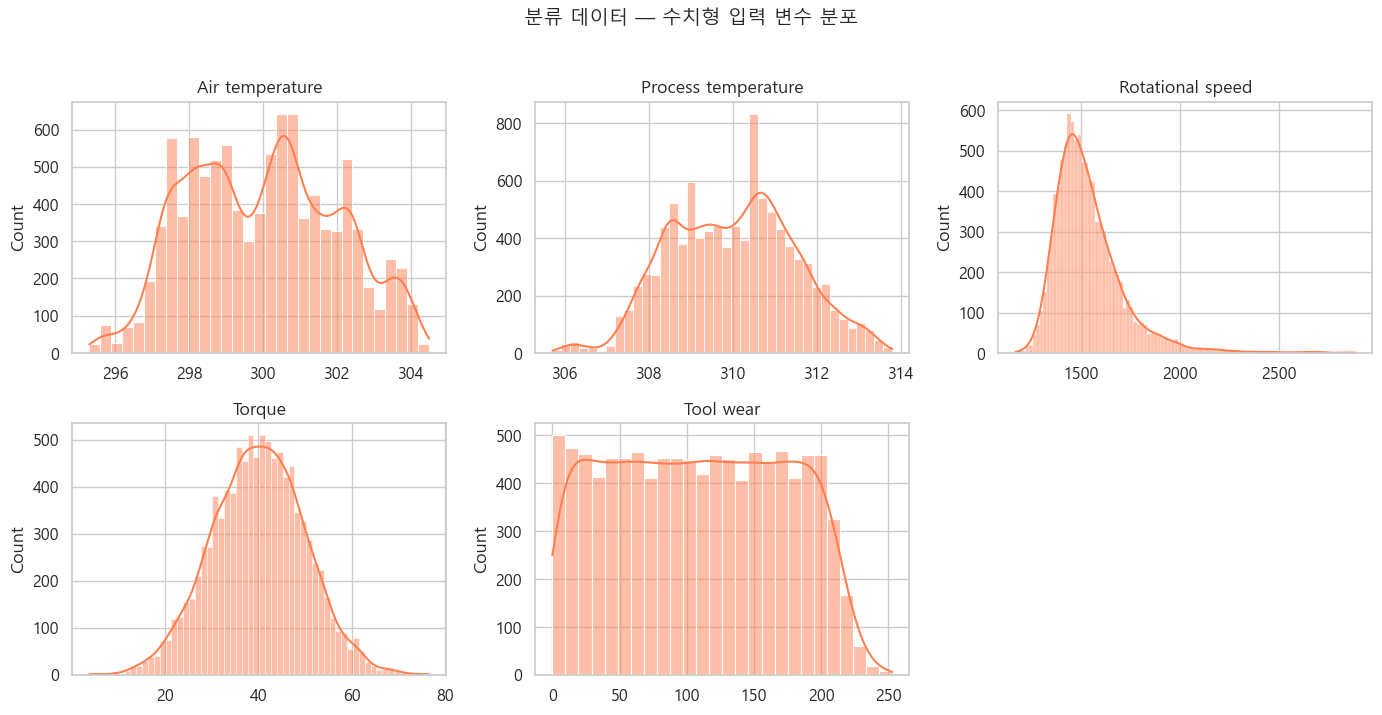

C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\3798602936.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Regression, x="Type", order=["L", "M", "H"], ax=axes[0], palette="Blues")
C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\3798602936.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Classification, x="Type", order=["L", "M", "H"], ax=axes[1], palette="Oranges")


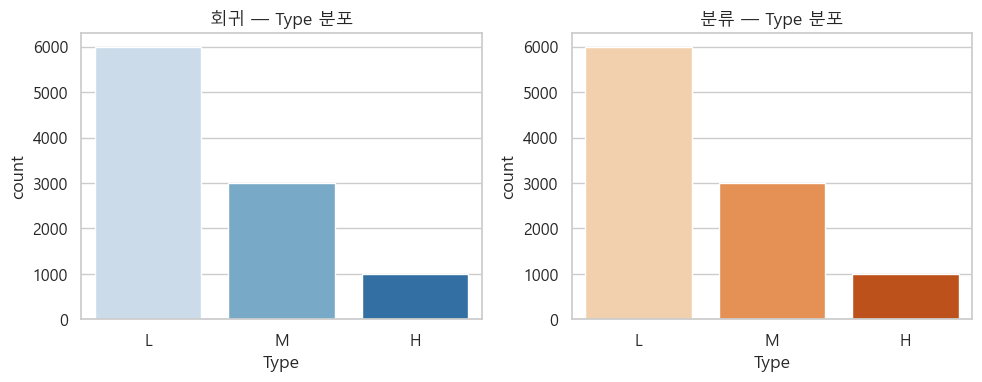

In [ ]:
# ===== 1-2-1) 단일 변수 분포 — 수치형 변수 히스토그램 =====

setup_korean_font()

# 수치형 변수만 추출
reg_num_cols = Regression.select_dtypes(include="number").columns.tolist()
clf_num_cols = [c for c in Classification.select_dtypes(include="number").columns if c != "Machine failure"]

# 회귀 데이터: 수치형 변수 분포 (2×3 서브플롯)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), reg_num_cols):
    sns.histplot(Regression[col], kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
fig.delaxes(axes[1, 2])  # 5개 변수 → 마지막 빈 칸 제거
fig.suptitle("회귀 데이터 — 수치형 변수 분포", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 분류 데이터: 수치형 입력 변수 분포
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), clf_num_cols):
    sns.histplot(Classification[col], kde=True, ax=ax, color="coral", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
fig.delaxes(axes[1, 2])
fig.suptitle("분류 데이터 — 수치형 입력 변수 분포", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 범주형 변수(Type) 분포
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=Regression, x="Type", order=["L", "M", "H"], ax=axes[0], palette="Blues")
axes[0].set_title("회귀 — Type 분포")
sns.countplot(data=Classification, x="Type", order=["L", "M", "H"], ax=axes[1], palette="Oranges")
axes[1].set_title("분류 — Type 분포")
plt.tight_layout()
plt.show()

**[과제]** 써니는 설비 고장이 실제로 얼마나 자주 발생하는지 궁금합니다. 고장 발생 빈도를 확인할 수 있는 방법을 AI와 함께 찾아보고, 그 결과를 시각화하거나 분석해 보세요. 이 결과가 앞으로의 분석(데이터 분할, 성능 평가 등)에 어떤 영향을 줄 수 있을지도 함께 생각해 보세요.

=== Machine failure 빈도 ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

=== 비율 ===
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2853303862.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, ax=axes[0], palette="Set2")
C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2853303862.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_ratio.index, y=failure_ratio.values, ax=axes[1], palette="Set2")


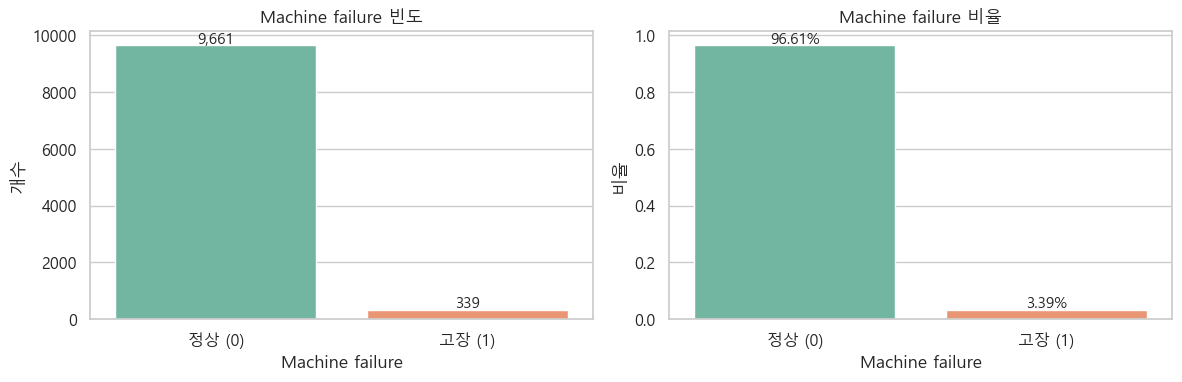


[분석 시 고려사항]
- 고장(1) 비율이 약 3.39%로 매우 낮은 불균형(imbalanced) 데이터입니다.
- train/test 분할 시 stratify=Classification['Machine failure']로 클래스 비율을 유지해야 합니다.
- accuracy만으로는 '전부 정상' 예측 모델도 높은 점수를 받을 수 있어, recall/F1/AUC 등을 함께 봐야 합니다.
- 필요 시 class_weight='balanced' 또는 SMOTE 등 불균형 대응 기법을 고려할 수 있습니다.


In [ ]:
# ===== 1-2-1) 고장 발생 빈도 =====

setup_korean_font()

failure_counts = Classification["Machine failure"].value_counts().sort_index()
failure_ratio = Classification["Machine failure"].value_counts(normalize=True).sort_index()

print("=== Machine failure 빈도 ===")
print(failure_counts)
print("\n=== 비율 ===")
print(failure_ratio.round(4))

# 막대 그래프 + 비율 표시
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ["정상 (0)", "고장 (1)"]
sns.barplot(x=failure_counts.index, y=failure_counts.values, ax=axes[0], palette="Set2")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels)
axes[0].set_title("Machine failure 빈도")
axes[0].set_ylabel("개수")
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=11)

sns.barplot(x=failure_ratio.index, y=failure_ratio.values, ax=axes[1], palette="Set2")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels)
axes[1].set_title("Machine failure 비율")
axes[1].set_ylabel("비율")
for i, v in enumerate(failure_ratio.values):
    axes[1].text(i, v + 0.005, f"{v:.2%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

# 분석 영향 요약
fail_rate = failure_ratio[1]
print(f"\n[분석 시 고려사항]")
print(f"- 고장(1) 비율이 약 {fail_rate:.2%}로 매우 낮은 불균형(imbalanced) 데이터입니다.")
print("- train/test 분할 시 stratify=Classification['Machine failure']로 클래스 비율을 유지해야 합니다.")
print("- accuracy만으로는 '전부 정상' 예측 모델도 높은 점수를 받을 수 있어, recall/F1/AUC 등을 함께 봐야 합니다.")
print("- 필요 시 class_weight='balanced' 또는 SMOTE 등 불균형 대응 기법을 고려할 수 있습니다.")

**[과제]** 써니는 설비가 고장 났을 때와 정상일 때 변수들의 분포가 어떻게 다른지 비교하고 싶습니다. 어떻게 비교하면 차이가 잘 드러날지 AI와 상의해서 방법을 정하고 직접 시각화해 보세요.

C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2933868325.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Machine failure")
C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2933868325.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Machine failure")
C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2933868325.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Machine failure")
C:\Users\Admin\AppData\Local\Temp\ipykernel_26608\2933868325.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an un

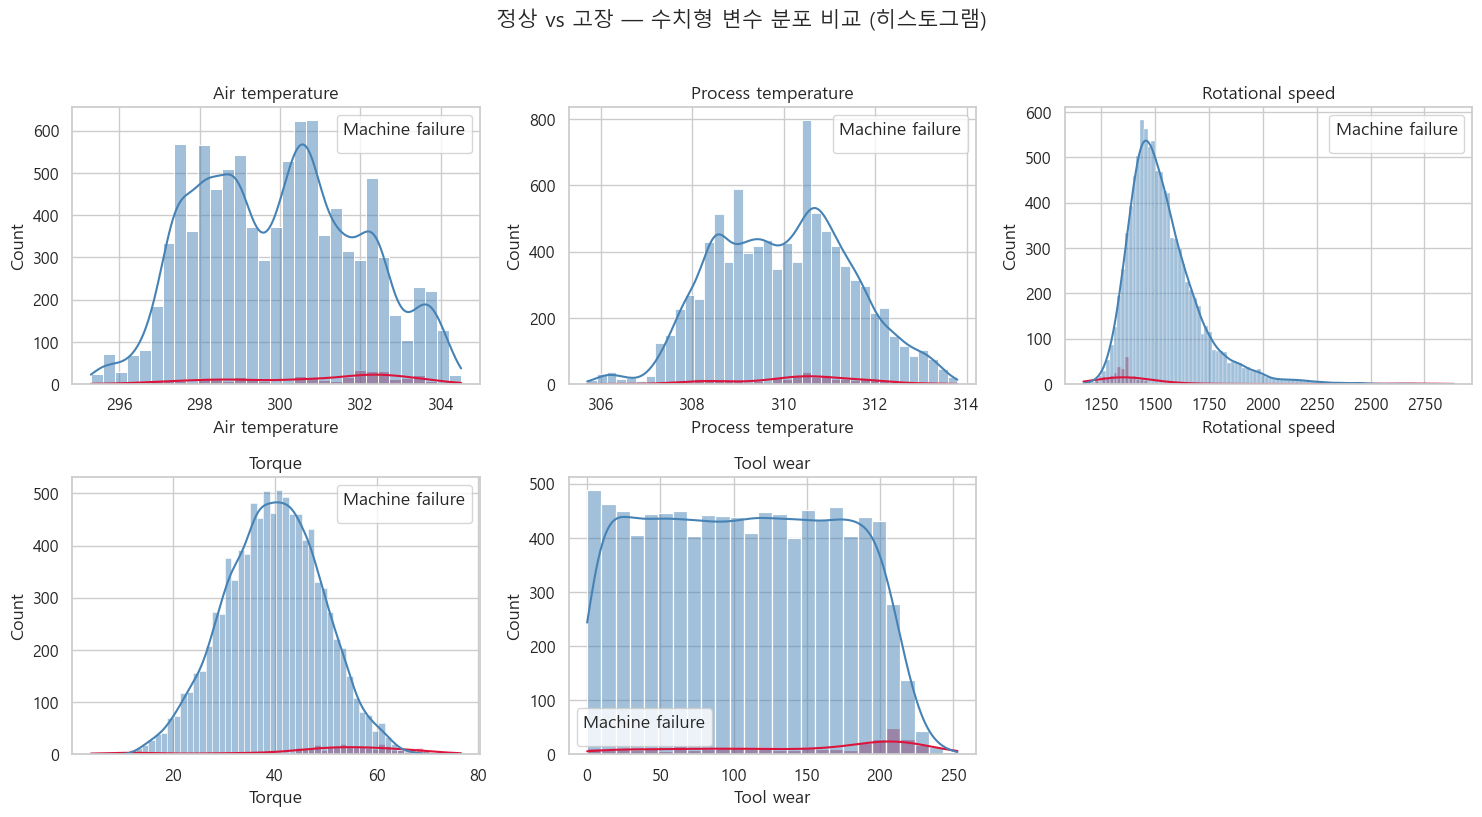

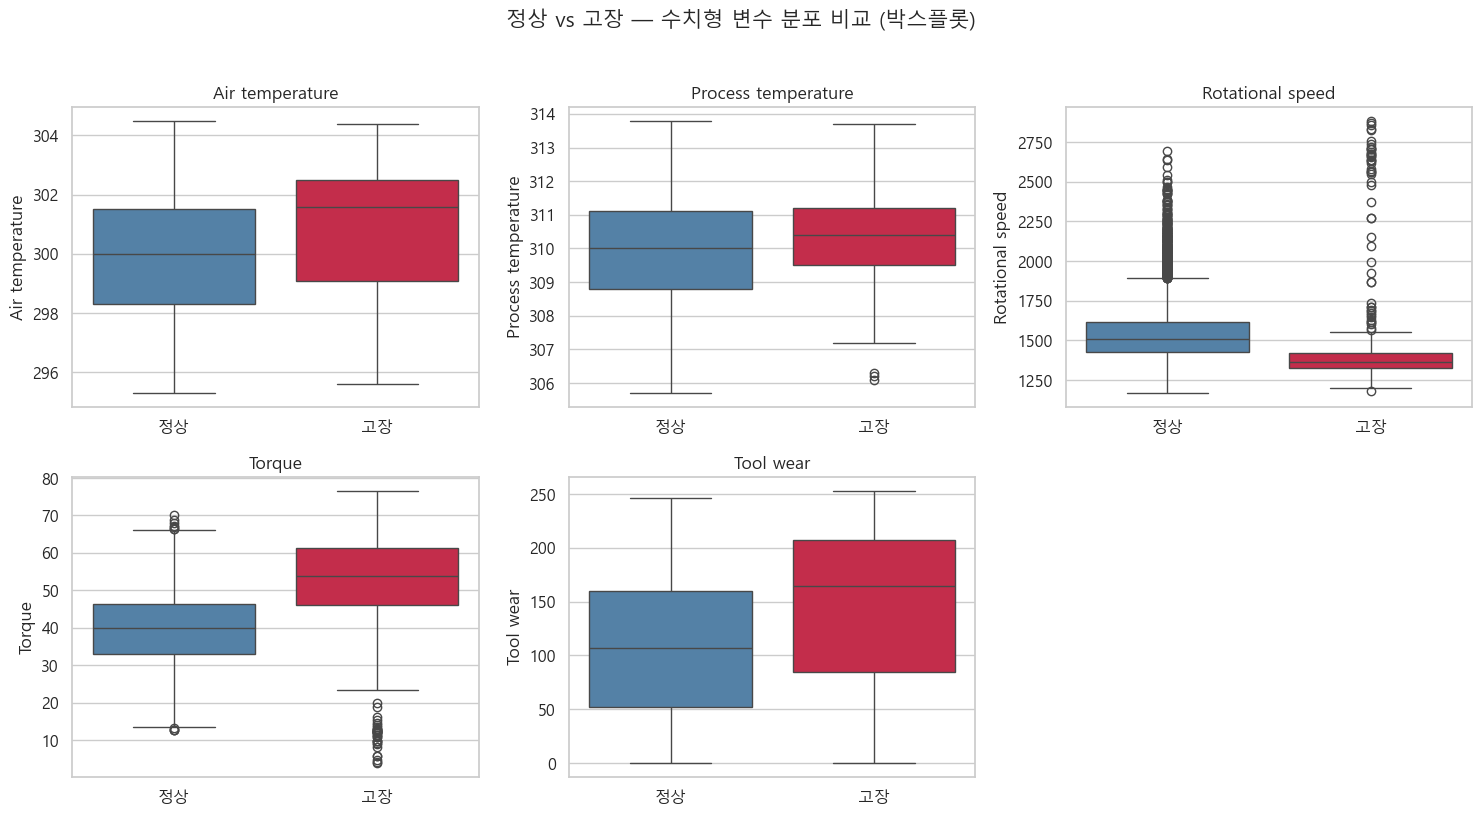

=== Type별 고장 발생 현황 ===


,전체,고장 수,고장 비율
Type,,,
H,1003,21,0.0209
L,6000,235,0.0392
M,2997,83,0.0277


In [ ]:
# ===== 1-2-1) 고장 vs 정상 — 변수 분포 비교 =====

setup_korean_font()

compare_cols = clf_num_cols  # 수치형 입력 변수
clf_compare = Classification.copy()
clf_compare["failure_label"] = clf_compare["Machine failure"].map({0: "정상", 1: "고장"})

# 1) 히스토그램: hue로 정상/고장 분리
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), compare_cols):
    sns.histplot(
        data=clf_compare,
        x=col,
        hue="failure_label",
        kde=True,
        ax=ax,
        palette={"정상": "steelblue", "고장": "crimson"},
        alpha=0.5,
        common_norm=False,
    )
    ax.set_title(col)
    ax.legend(title="Machine failure")
fig.delaxes(axes[1, 2])
fig.suptitle("정상 vs 고장 — 수치형 변수 분포 비교 (히스토그램)", y=1.02)
plt.tight_layout()
plt.show()

# 2) 박스플롯: 중앙값·사분위수 차이를 한눈에 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), compare_cols):
    sns.boxplot(
        data=clf_compare,
        x="failure_label",
        y=col,
        hue="failure_label",
        ax=ax,
        palette={"정상": "steelblue", "고장": "crimson"},
        legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("")
fig.delaxes(axes[1, 2])
fig.suptitle("정상 vs 고장 — 수치형 변수 분포 비교 (박스플롯)", y=1.02)
plt.tight_layout()
plt.show()

# 3) Type 범주별 고장 비율
type_failure = (
    Classification.groupby("Type")["Machine failure"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "전체", "sum": "고장 수", "mean": "고장 비율"})
)
print("=== Type별 고장 발생 현황 ===")
display(type_failure.round(4))

#### 1-2-2) 변수 간 관계

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

=== 회귀 데이터 상관계수 ===


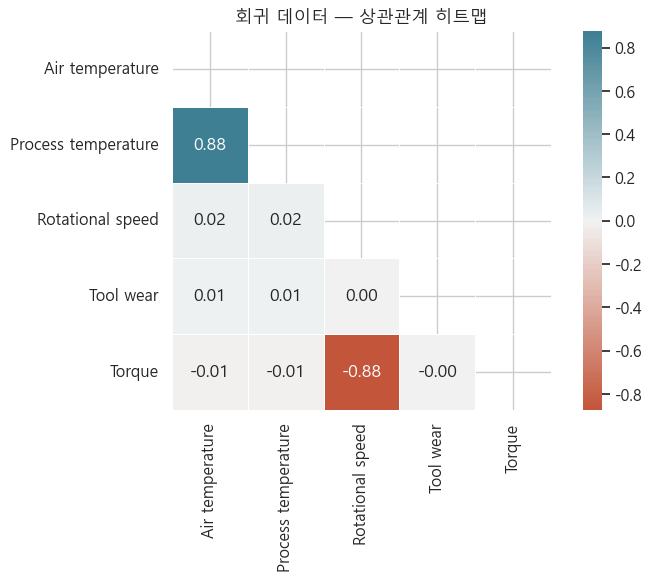


=== 분류 데이터 상관계수 (타겟 포함) ===


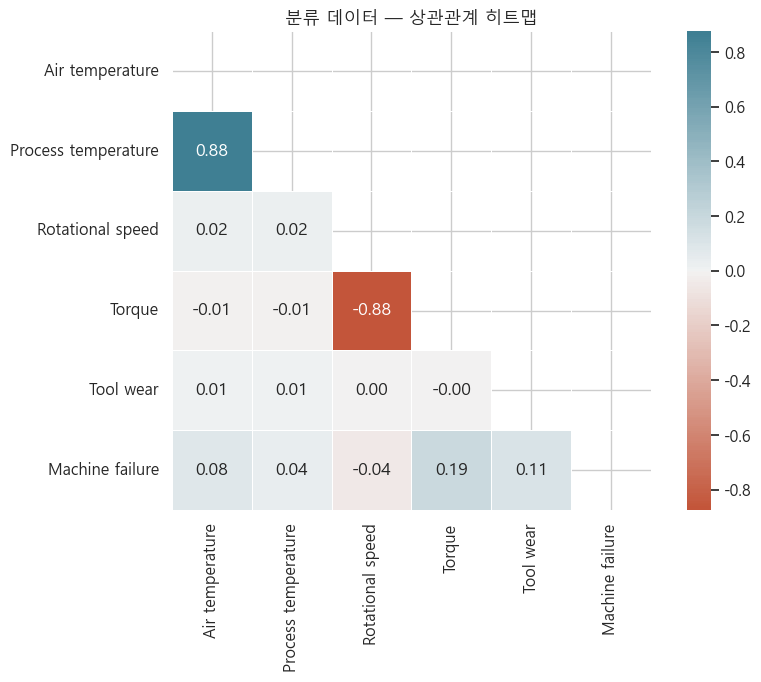


=== 회귀: |r| >= 0.7 변수쌍 ===
  Air temperature ↔ Process temperature: 0.876
  Rotational speed ↔ Torque: -0.875

=== 분류: |r| >= 0.7 변수쌍 ===
  Air temperature ↔ Process temperature: 0.876
  Rotational speed ↔ Torque: -0.875


In [ ]:
# ===== 1-2-2) 변수 간 상관관계 히트맵 =====

setup_korean_font()

def plot_corr_heatmap(df, title, figsize=(8, 6)):
    corr = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각형 마스크 (중복 제거)
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=sns.diverging_palette(20, 220, n=200),
        center=0,
        square=True,
        linewidths=0.5,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return corr

print("=== 회귀 데이터 상관계수 ===")
reg_corr = plot_corr_heatmap(Regression, "회귀 데이터 — 상관관계 히트맵", figsize=(8, 6))

print("\n=== 분류 데이터 상관계수 (타겟 포함) ===")
clf_corr = plot_corr_heatmap(Classification, "분류 데이터 — 상관관계 히트맵", figsize=(9, 7))

# |r| >= 0.7 인 다중공선성 후보 변수쌍 추출
THRESHOLD = 0.7

def find_high_corr_pairs(corr, threshold=0.7):
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append((cols[i], cols[j], r))
    return sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

print(f"\n=== 회귀: |r| >= {THRESHOLD} 변수쌍 ===")
for a, b, r in find_high_corr_pairs(reg_corr, THRESHOLD):
    print(f"  {a} ↔ {b}: {r:.3f}")

print(f"\n=== 분류: |r| >= {THRESHOLD} 변수쌍 ===")
for a, b, r in find_high_corr_pairs(clf_corr, THRESHOLD):
    print(f"  {a} ↔ {b}: {r:.3f}")

**[과제]** 써니는 히트맵으로 상관관계가 높은 변수쌍은 찾았지만, 단순한 상관계수만으로 변수들이 서로 얽혀 있는 정도를 다 설명할 수 있을지 의문이 듭니다. 상관계수 외에 변수 간의 강한 관계를 파악할 수 있는 다른 방법이 있는지 AI와 함께 찾아보고, 직접 적용해 보세요.

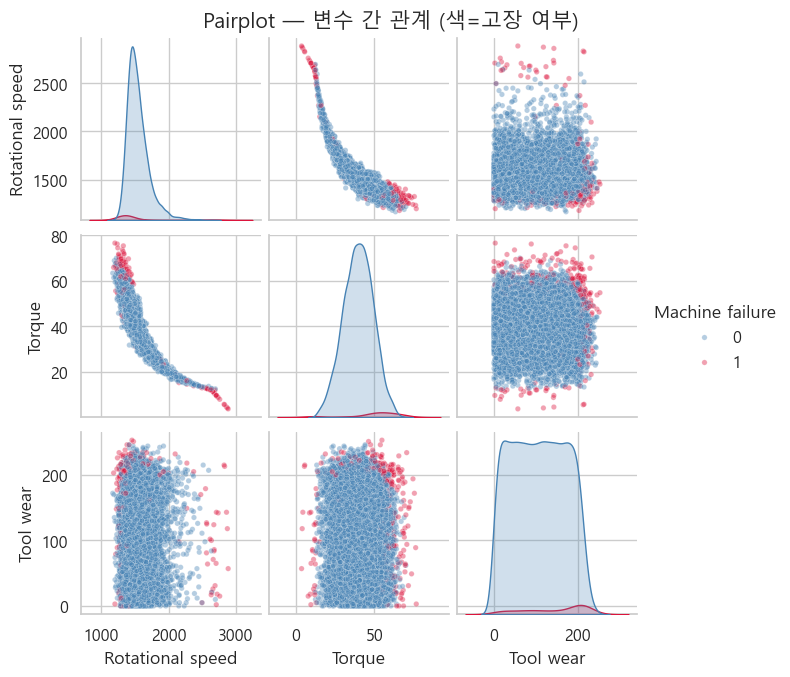

=== 분류: Machine failure와의 Mutual Information (높을수록 관련성 큼) ===


Torque                 0.0465
Rotational speed       0.0348
Tool wear              0.0132
Air temperature        0.0071
Process temperature    0.0034
Type_L                 0.0009
Type_H                 0.0007
Type_M                 0.0000
dtype: float64

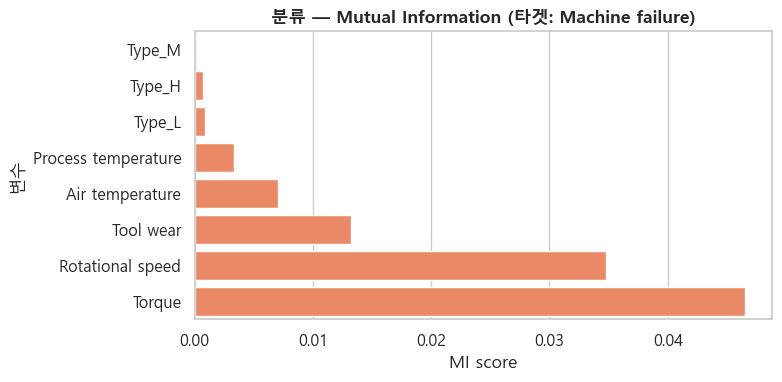


=== 회귀: Torque와의 Mutual Information ===


Rotational speed       1.0713
Air temperature        0.0140
Type_L                 0.0070
Type_M                 0.0056
Process temperature    0.0007
Type_H                 0.0000
Tool wear              0.0000
dtype: float64

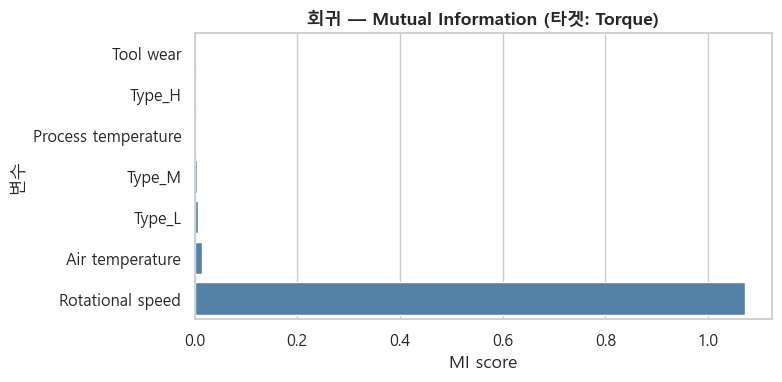


[해석]
- 상관계수: Air temperature ↔ Process temperature처럼 선형 관계가 강한 쌍을 찾기 좋습니다.
- Pairplot: Rotational speed vs Torque 등 비선형·이상치 패턴을 눈으로 확인할 수 있습니다.
- Mutual Information: 상관계수가 낮아도 타겟과 관련 있는 변수(예: Tool wear)를 추가로 발견할 수 있습니다.


In [ ]:
# ===== 1-2-2) 상관계수 외 변수 관계 탐색 =====

setup_korean_font()
# 상관계수는 선형 관계만 포착 → pairplot(산점도+분포)과 Mutual Information으로 보완

# 1) Pairplot: 비선형·군집 패턴을 산점도로 확인
pair_cols = ["Rotational speed", "Torque", "Tool wear", "Machine failure"]
sns.pairplot(
    Classification[pair_cols],
    hue="Machine failure",
    palette={0: "steelblue", 1: "crimson"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    height=2.2,
)
plt.suptitle("Pairplot — 변수 간 관계 (색=고장 여부)", y=1.02)
plt.show()

# 2) Mutual Information: 선형/비선형 관계를 수치로 비교
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# 분류: Machine failure와 각 입력 변수의 MI
X_clf = Classification.drop(columns=["Machine failure"])
X_clf_encoded = pd.get_dummies(X_clf, columns=["Type"], drop_first=False)
mi_clf = mutual_info_classif(
    X_clf_encoded, Classification["Machine failure"], random_state=42
)
mi_clf_series = pd.Series(mi_clf, index=X_clf_encoded.columns).sort_values(ascending=False)

print("=== 분류: Machine failure와의 Mutual Information (높을수록 관련성 큼) ===")
display(mi_clf_series.round(4))

setup_korean_font()
mi_clf_df = mi_clf_series.sort_values().reset_index()
mi_clf_df.columns = ["변수", "MI"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=mi_clf_df, y="변수", x="MI", ax=ax, color="coral", orient="h")
ax.set_title("분류 — Mutual Information (타겟: Machine failure)", fontweight="bold")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()

# 회귀: Torque와 각 입력 변수의 MI
X_reg = Regression.drop(columns=["Torque"])
X_reg_encoded = pd.get_dummies(X_reg, columns=["Type"], drop_first=False)
mi_reg = mutual_info_regression(
    X_reg_encoded, Regression["Torque"], random_state=42
)
mi_reg_series = pd.Series(mi_reg, index=X_reg_encoded.columns).sort_values(ascending=False)

print("\n=== 회귀: Torque와의 Mutual Information ===")
display(mi_reg_series.round(4))

setup_korean_font()
mi_reg_df = mi_reg_series.sort_values().reset_index()
mi_reg_df.columns = ["변수", "MI"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=mi_reg_df, y="변수", x="MI", ax=ax, color="steelblue", orient="h")
ax.set_title("회귀 — Mutual Information (타겟: Torque)", fontweight="bold")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()

print("\n[해석]")
print("- 상관계수: Air temperature ↔ Process temperature처럼 선형 관계가 강한 쌍을 찾기 좋습니다.")
print("- Pairplot: Rotational speed vs Torque 등 비선형·이상치 패턴을 눈으로 확인할 수 있습니다.")
print("- Mutual Information: 상관계수가 낮아도 타겟과 관련 있는 변수(예: Tool wear)를 추가로 발견할 수 있습니다.")

---
## 2) 데이터 전처리

### 2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델에 넣기 전에 분석에 도움이 안 되거나, 오히려 결과를 왜곡시킬 수 있는 변수가 있는지 점검하려고 합니다. 어떤 변수를 빼야 하는지, 그 이유는 무엇인지 AI와 상의해서 정리하고 제거해 보세요.

In [ ]:
# ===== 2-1) 불필요한 변수 제거 및 결측치 확인 =====

# 1) 결측치 확인
print("=== 결측치 ===")
print("Regression:\n", Regression.isnull().sum())
print("\nClassification:\n", Classification.isnull().sum())

# 2) 상수 변수 (nunique == 1) 확인
const_reg = Regression.columns[Regression.nunique() == 1].tolist()
const_clf = Classification.columns[Classification.nunique() == 1].tolist()
print(f"\n상수 변수 — Regression: {const_reg}, Classification: {const_clf}")

# 3) 완전 중복 변수 확인
dup_reg = Regression.T.duplicated()
dup_clf = Classification.T.duplicated()
print(f"중복 변수 — Regression: {Regression.columns[dup_reg].tolist()}")
print(f"중복 변수 — Classification: {Classification.columns[dup_clf].tolist()}")

# 4) 다중공선성 후보: |r| >= 0.85 변수쌍 탐색
CORR_THRESHOLD = 0.85

def find_high_corr_pairs(df, threshold=0.85):
    corr = df.corr(numeric_only=True)
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append((cols[i], cols[j], r))
    return pairs, corr

reg_pairs, reg_corr = find_high_corr_pairs(Regression, CORR_THRESHOLD)
clf_pairs, clf_corr = find_high_corr_pairs(Classification, CORR_THRESHOLD)

print(f"\n=== 회귀 |r| >= {CORR_THRESHOLD} 변수쌍 ===")
for a, b, r in reg_pairs:
    print(f"  {a} ↔ {b}: {r:.3f}")
print(f"\n=== 분류 |r| >= {CORR_THRESHOLD} 변수쌍 ===")
for a, b, r in clf_pairs:
    print(f"  {a} ↔ {b}: {r:.3f}")

# 5) 제거 결정
# - Air temperature ↔ Process temperature: 거의 동일 정보 → Process temperature 제거
# - (분류) Rotational speed ↔ Torque: 강한 상관이지만 물리적 의미가 달라 유지
#   (트리 모델은 다중공선성에 강하고, 선형 모델은 Ridge/Lasso로 완화 가능)
DROP_COLS = ["Process temperature"]

Regression_pp = Regression.drop(columns=DROP_COLS).copy()
Classification_pp = Classification.drop(columns=DROP_COLS).copy()

print(f"\n[제거 변수] {DROP_COLS}")
print(f"  이유: Air temperature와 상관계수 {reg_corr.loc['Air temperature', 'Process temperature']:.3f}로 중복 정보")
print(f"\n[전처리 후 shape] Regression: {Regression_pp.shape}, Classification: {Classification_pp.shape}")
display(Regression_pp.head(3))

=== 결측치 ===
Regression:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Tool wear              0
Torque                 0
dtype: int64

Classification:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
dtype: int64

상수 변수 — Regression: [], Classification: []
중복 변수 — Regression: []
중복 변수 — Classification: []

=== 회귀 |r| >= 0.85 변수쌍 ===
  Air temperature ↔ Process temperature: 0.876
  Rotational speed ↔ Torque: -0.875

=== 분류 |r| >= 0.85 변수쌍 ===
  Air temperature ↔ Process temperature: 0.876
  Rotational speed ↔ Torque: -0.875

[제거 변수] ['Process temperature']
  이유: Air temperature와 상관계수 0.876로 중복 정보

[전처리 후 shape] Regression: (10000, 5), Classification: (10000, 6)


,Type,Air temperature,Rotational speed,Tool wear,Torque
0,M,298.1,1551,0,42.8
1,L,298.2,1408,3,46.3
2,L,298.1,1498,5,49.4


### 2-2) 데이터 분할

**[과제]** 써니는 학습/테스트 데이터를 나누려고 합니다. 회귀용과 분류용 각각에 어떤 분할 방법과 기준이 적합할지 AI와 상의해서 정하고, 그 기준대로 직접 나눠 보세요.

In [ ]:
# ===== 2-2) 데이터 분할 =====
from sklearn.model_selection import train_test_split

# 입력(X) / 타겟(Y) 분리
X_reg = Regression_pp.drop(columns=[reg_target])
Y_reg = Regression_pp[reg_target]

X_clf = Classification_pp.drop(columns=[clf_target])
Y_clf = Classification_pp[clf_target]

# 회귀: 무작위 7:3 분할 (연속형 타겟 → stratify 불필요)
X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=42
)

# 분류: stratify로 고장(1) 비율 유지 (불균형 데이터)
X_clf_train, X_clf_test, Y_clf_train, Y_clf_test = train_test_split(
    X_clf, Y_clf, test_size=0.3, random_state=42, stratify=Y_clf
)

print("=== 회귀 분할 ===")
print(f"train: {X_reg_train.shape}, test: {X_reg_test.shape}")
print(f"Y_train mean: {Y_reg_train.mean():.2f}, Y_test mean: {Y_reg_test.mean():.2f}")

print("\n=== 분류 분할 ===")
print(f"train: {X_clf_train.shape}, test: {X_clf_test.shape}")
print("\n원본 고장 비율:")
print(Y_clf.value_counts(normalize=True).round(4))
print("\n학습 데이터 고장 비율:")
print(Y_clf_train.value_counts(normalize=True).round(4))
print("\n테스트 데이터 고장 비율:")
print(Y_clf_test.value_counts(normalize=True).round(4))

=== 회귀 분할 ===
train: (7000, 4), test: (3000, 4)
Y_train mean: 40.11, Y_test mean: 39.70

=== 분류 분할 ===
train: (7000, 5), test: (3000, 5)

원본 고장 비율:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

학습 데이터 고장 비율:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

테스트 데이터 고장 비율:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


### 2-3) 변수 스케일링

**[과제]** 써니는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 맞춰주고 싶습니다. 변수들의 분포를 보면서 어떤 스케일링 기법이 적합할지 AI와 상의해서 정하고 적용해 보세요.

In [ ]:
# ===== 2-3) 변수 스케일링 =====
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 스케일 차이 확인 (분류 데이터 수치형 예시)
sample_cols = ["Air temperature", "Rotational speed", "Torque", "Tool wear"]
print("=== 스케일링 전 ===")
display(X_clf_train[sample_cols].describe().loc[["min", "max", "mean", "std"]].round(3))

# Min-Max vs Standard 비교 (학습 데이터 기준)
mm = MinMaxScaler()
std = StandardScaler()
X_mm = pd.DataFrame(mm.fit_transform(X_clf_train[sample_cols]), columns=sample_cols)
X_std = pd.DataFrame(std.fit_transform(X_clf_train[sample_cols]), columns=sample_cols)

print("\n=== Min-Max 스케일링 후 ===")
display(X_mm.describe().loc[["min", "max", "mean", "std"]].round(3))
print("\n=== Standard 스케일링 후 ===")
display(X_std.describe().loc[["min", "max", "mean", "std"]].round(3))

# 결론: StandardScaler 선택
# - 선형 모델(Ridge, Logistic)과 L2 정규화 궁합이 좋음
# - Min-Max는 이상치(회전속도 등)에 민감 → 0~1 범위가 왜곡될 수 있음
# - 트리 모델은 스케일 불필요하지만, 이번 실습은 선형+트리 혼합 → Standard 통일

scaler_reg = StandardScaler()
scaler_clf = StandardScaler()

X_reg_train_scaled = X_reg_train.copy()
X_reg_test_scaled = X_reg_test.copy()
X_clf_train_scaled = X_clf_train.copy()
X_clf_test_scaled = X_clf_test.copy()

num_reg = X_reg_train_scaled.select_dtypes(include=[np.number]).columns
num_clf = X_clf_train_scaled.select_dtypes(include=[np.number]).columns

X_reg_train_scaled[num_reg] = scaler_reg.fit_transform(X_reg_train_scaled[num_reg])
X_reg_test_scaled[num_reg] = scaler_reg.transform(X_reg_test_scaled[num_reg])

X_clf_train_scaled[num_clf] = scaler_clf.fit_transform(X_clf_train_scaled[num_clf])
X_clf_test_scaled[num_clf] = scaler_clf.transform(X_clf_test_scaled[num_clf])

print("\n[적용] train fit → train/test transform (데이터 누수 방지)")
print(f"회귀 scaled mean: {X_reg_train_scaled[num_reg].mean().round(4).tolist()}")
print(f"분류 scaled std : {X_clf_train_scaled[num_clf].std().round(4).tolist()}")
display(X_reg_train_scaled.head(3))

=== 스케일링 전 ===


,Air temperature,Rotational speed,Torque,Tool wear
min,295.300,1168.000,3.800,0.000
max,304.500,2886.000,76.600,253.000
mean,300.014,1539.237,40.001,107.624
std,2.003,180.238,10.006,63.864



=== Min-Max 스케일링 후 ===


,Air temperature,Rotational speed,Torque,Tool wear
min,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000
mean,0.512,0.216,0.497,0.425
std,0.218,0.105,0.137,0.252



=== Standard 스케일링 후 ===


,Air temperature,Rotational speed,Torque,Tool wear
min,-2.354,-2.060,-3.618,-1.685
max,2.240,7.473,3.658,2.277
mean,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000



[적용] train fit → train/test transform (데이터 누수 방지)
회귀 scaled mean: [-0.0, -0.0, -0.0]
분류 scaled std : [1.0001, 1.0001, 1.0001, 1.0001]


,Type,Air temperature,Rotational speed,Tool wear
9069,M,-1.407205,0.773115,0.401499
2603,M,-0.356124,-1.124875,-1.214929
7738,M,0.244494,-1.516612,0.607514


**[과제]** 써니는 `Type` 변수를 모델에 넣으려면 숫자로 바꿔야 한다는 건 알고 있지만, 원-핫 인코딩과 라벨 인코딩 중 어느 쪽이 맞을지 고민입니다. 어떤 기준으로 선택해야 할지 AI와 상의해서 정하고 적용해 보세요.

In [ ]:
# ===== 2-3) Type 범주형 인코딩 =====

# Type(L/M/H)은 순서가 없는 명목형 → 원-핫 인코딩이 적합
# 라벨 인코딩(L=0,M=1,H=2)은 크기 관계가 생겨 선형/거리 기반 모델에 부적절

def onehot_encode(train_df, test_df, col="Type"):
    train_enc = pd.get_dummies(train_df, columns=[col], drop_first=True)
    test_enc = pd.get_dummies(test_df, columns=[col], drop_first=True)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)
    return train_enc, test_enc

X_reg_train_enc, X_reg_test_enc = onehot_encode(X_reg_train_scaled, X_reg_test_scaled)
X_clf_train_enc, X_clf_test_enc = onehot_encode(X_clf_train_scaled, X_clf_test_scaled)

# 모델링용 최종 데이터
X_reg_train_final = X_reg_train_enc.copy()
X_reg_test_final = X_reg_test_enc.copy()
Y_reg_train_final = Y_reg_train.copy()
Y_reg_test_final = Y_reg_test.copy()

X_clf_train_final = X_clf_train_enc.copy()
X_clf_test_final = X_clf_test_enc.copy()
Y_clf_train_final = Y_clf_train.copy()
Y_clf_test_final = Y_clf_test.copy()

print("[선택] 원-핫 인코딩 (drop_first=True → 기준 범주 L 제외, 다중공선성 방지)")
print(f"회귀 최종 feature: {X_reg_train_final.shape[1]}개 → {X_reg_train_final.columns.tolist()}")
print(f"분류 최종 feature: {X_clf_train_final.shape[1]}개 → {X_clf_train_final.columns.tolist()}")
display(X_reg_train_final.head())

[선택] 원-핫 인코딩 (drop_first=True → 기준 범주 L 제외, 다중공선성 방지)
회귀 최종 feature: 5개 → ['Air temperature', 'Rotational speed', 'Tool wear', 'Type_L', 'Type_M']
분류 최종 feature: 6개 → ['Air temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_L', 'Type_M']


,Air temperature,Rotational speed,Tool wear,Type_L,Type_M
9069,-1.407205,0.773115,0.401499,False,True
2603,-0.356124,-1.124875,-1.214929,False,True
7738,0.244494,-1.516612,0.607514,False,True
1579,-0.856639,-0.517960,1.082934,True,False
5058,1.946245,-0.065532,1.368186,True,False


---
## 3) 모델링

### 3-1) 모델 생성 및 학습

**[과제]** 써니는 여러 모델의 성능을 한 번에 비교해보고 싶습니다. 회귀와 분류 각각 어떤 모델을 후보로 둘지, 매번 코드를 새로 짜지 않고 효율적으로 비교할 방법은 무엇일지 AI와 상의해서 코드를 작성해 보세요.

In [ ]:
# ===== 3-1) 모델 생성 및 학습 =====
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# 회귀 모델 후보
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=100),
    "GBM": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0),
}

# 분류 모델 후보 (불균형 대응: class_weight='balanced')
cla_models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight="balanced"),
    "GBM": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, verbosity=0, scale_pos_weight=(Y_clf_train_final == 0).sum() / (Y_clf_train_final == 1).sum()),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0, auto_class_weights="Balanced"),
}

# 딕셔너리 + for 루프로 일괄 학습
for name, model in reg_models.items():
    model.fit(X_reg_train_final, Y_reg_train_final)
    print(f"[회귀] {name} 학습 완료")

print()
for name, model in cla_models.items():
    model.fit(X_clf_train_final, Y_clf_train_final)
    print(f"[분류] {name} 학습 완료")

[회귀] LinearRegression 학습 완료
[회귀] Ridge 학습 완료
[회귀] Lasso 학습 완료
[회귀] DecisionTree 학습 완료
[회귀] RandomForest 학습 완료
[회귀] GBM 학습 완료
[회귀] XGBoost 학습 완료
[회귀] CatBoost 학습 완료

[분류] Logistic 학습 완료
[분류] DecisionTree 학습 완료
[분류] RandomForest 학습 완료
[분류] GBM 학습 완료
[분류] XGBoost 학습 완료
[분류] CatBoost 학습 완료


### 3-2) 테스트 데이터 예측

**[과제]** 써니는 앞서 학습시킨 회귀 및 분류 모델들로 테스트 데이터에 대한 예측을 수행하려고 합니다. 모든 모델의 예측 결과를 한 번에 뽑을 수 있도록 AI와 함께 코드를 작성해 보세요.

In [ ]:
# ===== 3-2) 테스트 데이터 예측 =====

# 회귀: 연속값 예측
reg_preds = {}
for name, model in reg_models.items():
    reg_preds[name] = model.predict(X_reg_test_final)

# 분류: 클래스 + 양성(고장) 확률
cla_preds = {}
cla_probs = {}
for name, model in cla_models.items():
    cla_preds[name] = model.predict(X_clf_test_final)
    cla_probs[name] = model.predict_proba(X_clf_test_final)[:, 1]

# 예측 결과 미리보기
reg_pred_df = pd.DataFrame(reg_preds)
reg_pred_df["actual"] = Y_reg_test_final.values
reg_pred_df.index = Y_reg_test_final.index

cla_pred_df = pd.DataFrame(cla_preds)
cla_pred_df["actual"] = Y_clf_test_final.values
cla_pred_df.index = Y_clf_test_final.index

print("=== 회귀 예측 샘플 (상위 5행) ===")
display(reg_pred_df.head())

print("\n=== 분류 예측 샘플 (상위 5행) ===")
display(cla_pred_df.head())

print(f"\n총 {len(reg_models)}개 회귀 모델, {len(cla_models)}개 분류 모델 예측 완료")

=== 회귀 예측 샘플 (상위 5행) ===


,LinearRegression,Ridge,Lasso,DecisionTree,RandomForest,GBM,XGBoost,CatBoost,actual
6252,40.110065,40.110026,40.103767,38.4,38.740,37.671955,37.218769,37.646068,36.1
4684,45.934133,45.933168,45.120136,39.9,45.351,46.517544,45.544159,45.573872,44.8
1731,42.563966,42.563541,42.376139,41.9,41.927,41.902782,43.012035,42.119487,42.0
4742,37.766700,37.766939,37.788520,29.8,34.070,34.606067,34.330669,34.457445,33.7
4521,24.416178,24.418352,26.083659,25.9,24.999,23.916469,23.794176,23.489309,23.9



=== 분류 예측 샘플 (상위 5행) ===


,Logistic,DecisionTree,RandomForest,GBM,XGBoost,CatBoost,actual
7809,0,0,0,0,0,0,0
9069,0,0,0,0,0,0,0
3170,0,0,0,0,0,0,0
2750,0,0,0,0,0,0,0
6986,0,0,0,0,0,0,0



총 8개 회귀 모델, 6개 분류 모델 예측 완료


### 3-3) 성능 평가

**[과제]** 써니는 모델 성능을 비교하려고 하는데, 회귀와 분류 각각 사용할 수 있는 지표가 다양해서 무엇을 기준으로 봐야 할지 고민입니다. 적절한 지표를 AI와 상의해서 정하고, 그 기준으로 가장 좋은 모델을 선택해 보세요.

In [ ]:
# ===== 3-3) 성능 평가 =====
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
)

def get_reg_score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "MSE": mse, "MAPE(%)": mape}

def get_cla_score(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "G-Mean": np.sqrt(recall * specificity),
        "AUC": roc_auc_score(y_true, y_prob),
    }

# 회귀: MAE 기준 (오차가 작을수록 좋음)
reg_results = {name: get_reg_score(Y_reg_test_final, reg_preds[name]) for name in reg_models}
reg_score_df = pd.DataFrame(reg_results).T.round(4).sort_values("MAE")

print("=== 회귀 성능 (MAE 오름차순) ===")
display(reg_score_df)

# 분류: F1 기준 (불균형 데이터에서 accuracy보다 적합)
cla_results = {name: get_cla_score(Y_clf_test_final, cla_preds[name], cla_probs[name]) for name in cla_models}
cla_score_df = pd.DataFrame(cla_results).T.round(4).sort_values("F1", ascending=False)

print("\n=== 분류 성능 (F1 내림차순) ===")
display(cla_score_df)

# 최고 모델 선택
best_reg_name = reg_score_df.index[0]
best_cla_name = cla_score_df.index[0]

print(f"\n[최종 선택]")
print(f"- 회귀 최고 모델: {best_reg_name} (MAE={reg_score_df.loc[best_reg_name, 'MAE']:.4f})")
print(f"- 분류 최고 모델: {best_cla_name} (F1={cla_score_df.loc[best_cla_name, 'F1']:.4f}, AUC={cla_score_df.loc[best_cla_name, 'AUC']:.4f})")
print("\n[지표 선택 근거]")
print("- 회귀: MAE — 토크(Nm) 단위로 해석이 직관적")
print("- 분류: F1 + AUC — 고장(1) 비율이 낮아 accuracy만으로는 모델 품질을 판단하기 어려움")

=== 회귀 성능 (MAE 오름차순) ===


,MAE,MSE,MAPE(%)
GBM,2.9516,15.7029,7.2344
CatBoost,3.0251,16.4159,7.4700
RandomForest,3.1331,17.5362,7.6697
XGBoost,3.1915,18.1639,7.8659
LinearRegression,3.6305,23.0539,10.1458
Ridge,3.6306,23.0543,10.1458
Lasso,3.8147,24.2770,10.3681
DecisionTree,4.2157,30.5806,10.3368



=== 분류 성능 (F1 내림차순) ===


,Accuracy,Recall,Precision,Specificity,F1,G-Mean,AUC
CatBoost,0.9620,0.7843,0.4651,0.9683,0.5839,0.8714,0.9594
XGBoost,0.9687,0.6176,0.5339,0.9810,0.5727,0.7784,0.9664
GBM,0.9763,0.4118,0.7925,0.9962,0.5419,0.6405,0.9714
DecisionTree,0.9683,0.4118,0.5455,0.9879,0.4693,0.6378,0.6998
RandomForest,0.9733,0.3431,0.7292,0.9955,0.4667,0.5845,0.9569
Logistic,0.8203,0.7451,0.1290,0.8230,0.2200,0.7831,0.8765



[최종 선택]
- 회귀 최고 모델: GBM (MAE=2.9516)
- 분류 최고 모델: CatBoost (F1=0.5839, AUC=0.9594)

[지표 선택 근거]
- 회귀: MAE — 토크(Nm) 단위로 해석이 직관적
- 분류: F1 + AUC — 고장(1) 비율이 낮아 accuracy만으로는 모델 품질을 판단하기 어려움


---
## 4) 모델 고도화

**[과제]** 써니는 가장 성능이 좋았던 모델을 더 끌어올리고 싶습니다. 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 AI와 상의해서 정하고, 그 기준으로 성능을 높여 보세요.

In [ ]:
# ===== 4) 모델 고도화 =====
# 탐색 방법 선택
# - GridSearchCV: 후보 조합이 적을 때 (Ridge alpha, Logistic C 등)
# - RandomizedSearchCV: 파라미터·조합이 많을 때 (CatBoost, GBM, RF, XGBoost)
# 탐색 대상: 3) 최고 모델 + CatBoost

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform

print(f"3) 기준 최고 모델 — 회귀: {best_reg_name} | 분류: {best_cla_name}")

tune_reg_targets = list(dict.fromkeys([best_reg_name, "CatBoost"]))
tune_cla_targets = list(dict.fromkeys([best_cla_name, "CatBoost"]))

pos_weight = (Y_clf_train_final == 0).sum() / max((Y_clf_train_final == 1).sum(), 1)


def get_reg_search_space(name):
    if name == "Ridge":
        return Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}, "grid", None
    if name == "Lasso":
        return Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}, "grid", None
    if name == "LinearRegression":
        return Ridge(), {"alpha": loguniform(1e-4, 1e3)}, "random", 15
    if name == "DecisionTree":
        return DecisionTreeRegressor(random_state=42), {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_leaf": [1, 2, 5, 10],
        }, "random", 15
    if name == "RandomForest":
        return RandomForestRegressor(random_state=42), {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15, None],
            "min_samples_leaf": [1, 2, 4],
        }, "random", 15
    if name == "GBM":
        return GradientBoostingRegressor(random_state=42), {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
        }, "random", 15
    if name == "XGBoost":
        return XGBRegressor(random_state=42, verbosity=0), {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.05, 0.1],
        }, "random", 15
    if name == "CatBoost":
        return CatBoostRegressor(random_state=42, verbose=0), {
            "depth": [4, 6, 8, 10],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "iterations": [200, 400, 600, 800],
            "l2_leaf_reg": [1, 3, 5, 7, 10],
        }, "random", 20
    raise ValueError(f"회귀 탐색 공간 미정의: {name}")


def get_cla_search_space(name):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42), {
            "C": [0.01, 0.1, 1.0, 10.0, 100.0]
        }, "grid", None
    if name == "DecisionTree":
        return DecisionTreeClassifier(random_state=42, class_weight="balanced"), {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_leaf": [1, 2, 5, 10],
        }, "random", 15
    if name == "RandomForest":
        return RandomForestClassifier(random_state=42, class_weight="balanced"), {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15, None],
            "min_samples_leaf": [1, 2, 4],
        }, "random", 15
    if name == "GBM":
        return GradientBoostingClassifier(random_state=42), {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
        }, "random", 15
    if name == "XGBoost":
        return XGBClassifier(random_state=42, verbosity=0, scale_pos_weight=pos_weight), {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.05, 0.1],
        }, "random", 15
    if name == "CatBoost":
        return CatBoostClassifier(random_state=42, verbose=0, auto_class_weights="Balanced"), {
            "depth": [4, 6, 8, 10],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "iterations": [200, 400, 600, 800],
            "l2_leaf_reg": [1, 3, 5, 7, 10],
            "subsample": [0.6, 0.8, 1.0],
        }, "random", 20
    raise ValueError(f"분류 탐색 공간 미정의: {name}")


def run_search(estimator, param_space, method, n_iter, X_train, y_train, scoring):
    if method == "grid":
        search = GridSearchCV(estimator, param_space, cv=5, scoring=scoring, refit=True, n_jobs=-1)
    else:
        search = RandomizedSearchCV(
            estimator, param_space, n_iter=n_iter, cv=5, scoring=scoring,
            refit=True, random_state=42, n_jobs=-1,
        )
    search.fit(X_train, y_train)
    return search


reg_tuning_rows = []
reg_tuned_models = {}

for name in tune_reg_targets:
    est, param_space, method, n_iter = get_reg_search_space(name)
    search = run_search(
        est, param_space, method, n_iter,
        X_reg_train_final, Y_reg_train_final, "neg_mean_absolute_error",
    )
    baseline_mae = reg_score_df.loc[name, "MAE"]
    tuned_mae = mean_absolute_error(Y_reg_test_final, search.predict(X_reg_test_final))
    cv_mae = -search.best_score_
    reg_tuned_models[name] = search.best_estimator_
    reg_tuning_rows.append({
        "태스크": "회귀",
        "모델": name,
        "탐색방법": "GridSearchCV" if method == "grid" else f"RandomizedSearchCV(n={n_iter})",
        "best params": search.best_params_,
        "CV MAE": round(cv_mae, 4),
        "기본 Test MAE": round(baseline_mae, 4),
        "튜닝 Test MAE": round(tuned_mae, 4),
        "개선": round(baseline_mae - tuned_mae, 4),
    })

cla_tuning_rows = []
cla_tuned_models = {}

for name in tune_cla_targets:
    est, param_space, method, n_iter = get_cla_search_space(name)
    search = run_search(
        est, param_space, method, n_iter,
        X_clf_train_final, Y_clf_train_final, "f1",
    )
    baseline_f1 = cla_score_df.loc[name, "F1"]
    tuned_pred = search.predict(X_clf_test_final)
    tuned_f1 = f1_score(Y_clf_test_final, tuned_pred)
    cla_tuned_models[name] = search.best_estimator_
    cla_tuning_rows.append({
        "태스크": "분류",
        "모델": name,
        "탐색방법": "GridSearchCV" if method == "grid" else f"RandomizedSearchCV(n={n_iter})",
        "best params": search.best_params_,
        "CV F1": round(search.best_score_, 4),
        "기본 Test F1": round(baseline_f1, 4),
        "튜닝 Test F1": round(tuned_f1, 4),
        "개선": round(tuned_f1 - baseline_f1, 4),
    })

tuning_results = pd.DataFrame(reg_tuning_rows + cla_tuning_rows)
print("=== 하이퍼파라미터 탐색 결과 ===")
display(tuning_results)

# 튜닝 후 최종 모델 선택
best_reg_final_name = tuning_results[tuning_results["태스크"] == "회귀"].sort_values("튜닝 Test MAE").iloc[0]["모델"]
best_cla_final_name = tuning_results[tuning_results["태스크"] == "분류"].sort_values("튜닝 Test F1", ascending=False).iloc[0]["모델"]

best_reg_final_model = reg_tuned_models[best_reg_final_name]
best_cla_final_model = cla_tuned_models[best_cla_final_name]

best_reg_final_mae = tuning_results[
    (tuning_results["태스크"] == "회귀") & (tuning_results["모델"] == best_reg_final_name)
]["튜닝 Test MAE"].iloc[0]
best_cla_final_f1 = tuning_results[
    (tuning_results["태스크"] == "분류") & (tuning_results["모델"] == best_cla_final_name)
]["튜닝 Test F1"].iloc[0]

print(f"\n[최종 선택] 회귀: {best_reg_final_name} (Test MAE={best_reg_final_mae:.4f})")
print(f"[최종 선택] 분류: {best_cla_final_name} (Test F1={best_cla_final_f1:.4f})")

3) 기준 최고 모델 — 회귀: GBM | 분류: CatBoost
=== 하이퍼파라미터 탐색 결과 ===


,태스크,모델,탐색방법,best params,CV MAE,기본 Test MAE,튜닝 Test MAE,개선,CV F1,기본 Test F1,튜닝 Test F1
0,회귀,GBM,RandomizedSearchCV(n=15),"{'n_estimators': 100, 'max_depth': 3, 'learnin...",2.9482,2.9516,2.9461,0.0055,NaN,NaN,NaN
1,회귀,CatBoost,RandomizedSearchCV(n=20),"{'learning_rate': 0.01, 'l2_leaf_reg': 10, 'it...",2.9500,3.0251,2.9470,0.0781,NaN,NaN,NaN
2,분류,CatBoost,RandomizedSearchCV(n=20),"{'subsample': 1.0, 'learning_rate': 0.05, 'l2_...",NaN,NaN,NaN,-0.0147,0.5887,0.5839,0.5692



[최종 선택] 회귀: GBM (Test MAE=2.9461)
[최종 선택] 분류: CatBoost (Test F1=0.5692)


---
## 5) 모델 결과 분석

**[과제]** 써니는 최종적으로 어떤 운전 조건이 토크와 고장에 가장 큰 영향을 미치는지 정리해서 보고하려고 합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델의 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아본 뒤, 그 결과로부터 인사이트를 도출해 보세요.

회귀 최종 모델: GBM
분류 최종 모델: CatBoost


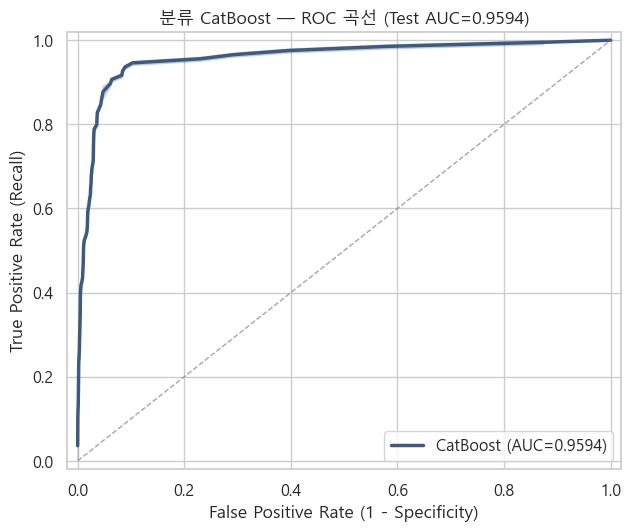

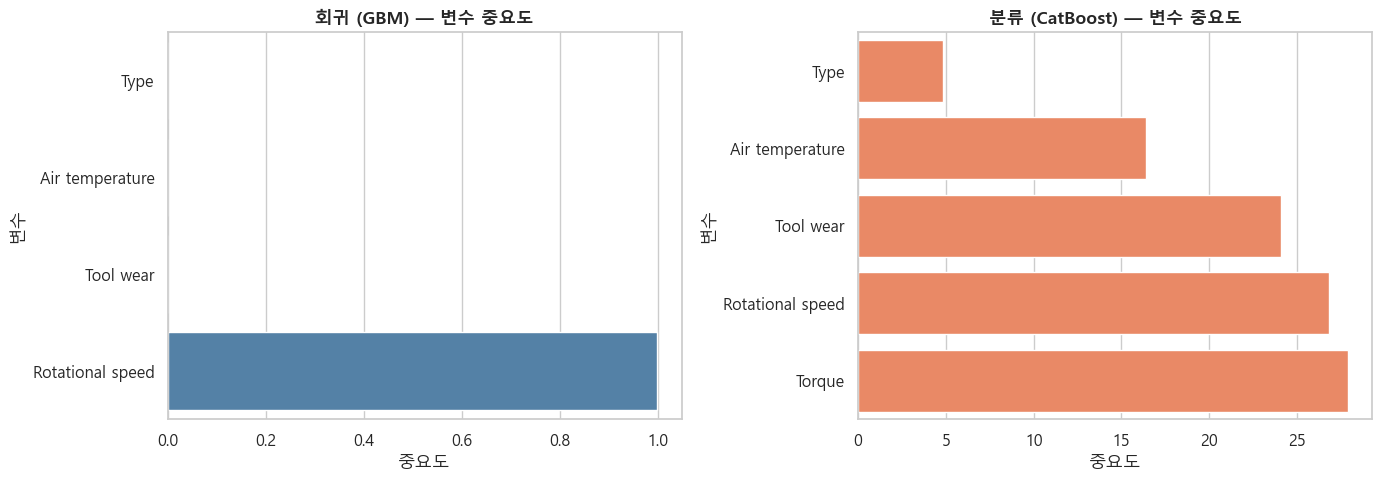


=== 회귀 Top 변수 (Torque 예측) ===


,importance
Rotational speed,0.9983
Tool wear,0.0010
Air temperature,0.0006
Type,0.0001



=== 분류 Top 변수 (Machine failure 예측) ===


,importance
Torque,27.8883
Rotational speed,26.8158
Tool wear,24.0720
Air temperature,16.4191
Type,4.8049



=== 인사이트 요약 ===
• 회귀: 'Rotational speed'이(가) Torque 예측에 가장 큰 영향
• 분류: 'Torque'이(가) 고장 예측에 가장 큰 영향
• 분류 CatBoost Test AUC: 0.9594
• 두 태스크 Top3 공통 변수: ['Rotational speed', 'Tool wear']


In [ ]:
# ===== 5) 모델 결과 분석 — 변수 중요도 · CatBoost ROC/AUC =====
from sklearn.metrics import roc_curve, roc_auc_score

setup_korean_font()


def get_feature_importance(model, feature_names):
    """선형 모델(|계수|) / 트리·부스팅 모델(feature_importances_) 공통 추출"""
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        coef = model.coef_
        values = np.abs(coef.ravel() if coef.ndim > 1 else coef)
    else:
        raise ValueError("변수 중요도를 추출할 수 없는 모델입니다.")
    return pd.Series(values, index=feature_names, name="importance").sort_values(ascending=False)


def aggregate_type_importance(importance_series):
    """원-핫 인코딩된 Type_* 변수를 Type 하나로 합산"""
    agg = {}
    for feat, val in importance_series.items():
        if feat.startswith("Type_"):
            agg["Type"] = agg.get("Type", 0) + val
        else:
            agg[feat] = agg.get(feat, 0) + val
    return pd.Series(agg, name="importance").sort_values(ascending=False)


print(f"회귀 최종 모델: {best_reg_final_name}")
print(f"분류 최종 모델: {best_cla_final_name}")

reg_imp_raw = get_feature_importance(best_reg_final_model, X_reg_train_final.columns)
cla_imp_raw = get_feature_importance(best_cla_final_model, X_clf_train_final.columns)

reg_imp = aggregate_type_importance(reg_imp_raw)
cla_imp = aggregate_type_importance(cla_imp_raw)

# --- 분류 CatBoost 최종 모델 ROC / AUC ---
cat_clf_model = cla_tuned_models.get("CatBoost", best_cla_final_model)
y_prob_cat = cat_clf_model.predict_proba(X_clf_test_final)[:, 1]
fpr, tpr, _ = roc_curve(Y_clf_test_final, y_prob_cat)
auc_cat = roc_auc_score(Y_clf_test_final, y_prob_cat)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.lineplot(x=fpr, y=tpr, ax=ax, lw=2.5, color="#3D5A80",
             label=f"CatBoost (AUC={auc_cat:.4f})")
sns.lineplot(x=[0, 1], y=[0, 1], ax=ax, color="gray", linestyle="--", lw=1, alpha=0.7, legend=False)
ax.set(xlabel="False Positive Rate (1 - Specificity)",
       ylabel="True Positive Rate (Recall)",
       title=f"분류 CatBoost — ROC 곡선 (Test AUC={auc_cat:.4f})",
       xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --- 변수 중요도 (seaborn barplot) ---
reg_plot_df = reg_imp.sort_values().reset_index()
reg_plot_df.columns = ["변수", "중요도"]
cla_plot_df = cla_imp.sort_values().reset_index()
cla_plot_df.columns = ["변수", "중요도"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=reg_plot_df, y="변수", x="중요도", ax=axes[0], color="steelblue", orient="h")
axes[0].set_title(f"회귀 ({best_reg_final_name}) — 변수 중요도", fontweight="bold")
axes[0].set_xlabel("중요도")

sns.barplot(data=cla_plot_df, y="변수", x="중요도", ax=axes[1], color="coral", orient="h")
axes[1].set_title(f"분류 ({best_cla_final_name}) — 변수 중요도", fontweight="bold")
axes[1].set_xlabel("중요도")

plt.tight_layout()
plt.show()

print("\n=== 회귀 Top 변수 (Torque 예측) ===")
display(reg_imp.round(4).to_frame())

print("\n=== 분류 Top 변수 (Machine failure 예측) ===")
display(cla_imp.round(4).to_frame())

print("\n=== 인사이트 요약 ===")
print(f"• 회귀: '{reg_imp.index[0]}'이(가) Torque 예측에 가장 큰 영향")
print(f"• 분류: '{cla_imp.index[0]}'이(가) 고장 예측에 가장 큰 영향")
print(f"• 분류 CatBoost Test AUC: {auc_cat:.4f}")

common_vars = set(reg_imp.head(3).index) & set(cla_imp.head(3).index)
if common_vars:
    print(f"• 두 태스크 Top3 공통 변수: {sorted(common_vars)}")
else:
    print("• 두 태스크 Top3에 공통 변수 없음 → 회귀/분류는 서로 다른 관점으로 예측")
